# Exploratory Data Analysis

This notebook will hold exploratory visuals, summaries, and pattern checks for the Liberty Heritage dataset.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

DATA_PATH = Path('data/raw/Liberty_Heritage_Data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/raw/Liberty_Heritage_Data.csv')

df = pd.read_csv(DATA_PATH)

print(f'Loaded {DATA_PATH} with shape {df.shape}')
print(df.head().to_string(index=False))

Loaded ../data/raw/Liberty_Heritage_Data.csv with shape (8000, 25)
ApplicationID  Age Gender MaritalStatus  Dependents EducationLevel State       ResidenceType  YearsAtCurrentResidence      EmploymentType  Employed  EmploymentLengthYears  AnnualIncome  IncomeVerified  CreditScore  CreditHistoryMonths  ExistingLoanAccounts  ExistingCreditCards  TotalMonthlyDebtPayment  DebtToIncomeRatio  RevolvingUtilization  PriorDefault  BankruptcyLast7Years  EnquiriesLast6Months Approval
  LHB-2403641   60 Female      Divorced           4     Bachelor's    GA                Rent                      2.0 Salaried-Government         1                    2.0         100.2               1          513                  369                     4                    3                   2271.0              0.272                 0.484             1                     0                     3       No
  LHB-2405086   28   Male       Married           1      Doctorate    KY Own (with mortgage)                   

## EDA Plan

- Review target balance
- Inspect numeric distributions
- Compare categorical features against the target
- Check for obvious relationships and unusual patterns

## Credit Score Distribution

The histogram below shows the CreditScore distribution with standard FICO band cutoffs marked for reference. The table reports the number and share of applicants in each band.

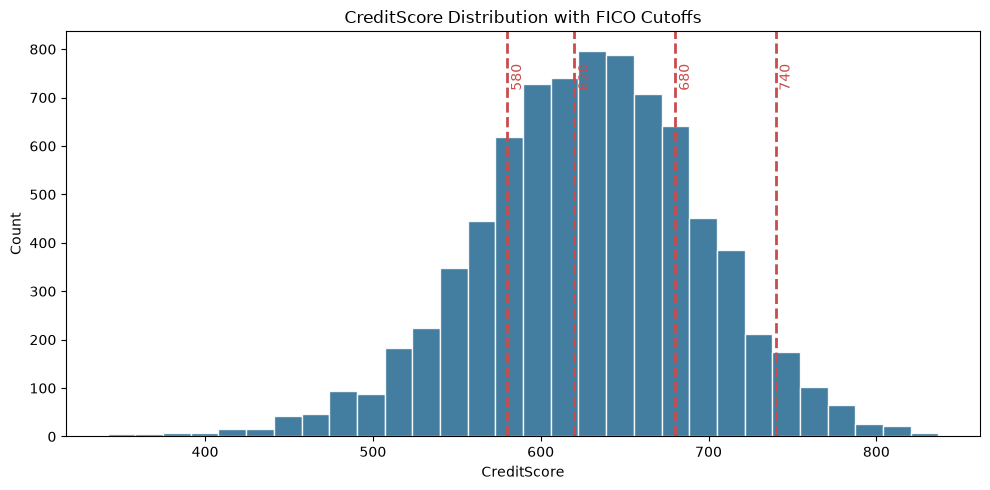

             count  percentage
CreditScore                   
<580          1774       22.18
580-619       1714       21.42
620-679       2746       34.33
680-739       1391       17.39
740+           375        4.69


In [2]:
fico_cutoffs = [580, 620, 680, 740]
fico_band_labels = ['<580', '580-619', '620-679', '680-739', '740+']
fico_band_bins = [-float('inf')] + fico_cutoffs + [float('inf')]

fico_bands = pd.cut(df['CreditScore'], bins=fico_band_bins, labels=fico_band_labels, right=False)
fico_band_summary = pd.DataFrame({'count': fico_bands.value_counts().reindex(fico_band_labels)})
fico_band_summary['percentage'] = (fico_band_summary['count'] / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['CreditScore'], bins=30, color='#2E6F95', edgecolor='white', alpha=0.9)
for cutoff in fico_cutoffs:
    ax.axvline(cutoff, color='#C94C4C', linestyle='--', linewidth=2)
    ax.text(cutoff + 2, ax.get_ylim()[1] * 0.92, str(cutoff), color='#C94C4C', rotation=90, va='top')
ax.set_title('CreditScore Distribution with FICO Cutoffs')
ax.set_xlabel('CreditScore')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(fico_band_summary.to_string())

## Debt-To-Income Ratio

This view combines a histogram and box plot for `DebtToIncomeRatio`, with reference lines at 0.36 and 0.50. Missing values are excluded from the chart and percentile calculations.

/var/folders/bs/0dgg3xzx0gn8v4gn7_6k83xh0000gn/T/ipykernel_25267/1690739735.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(dti, vert=True, patch_artist=True, boxprops={'facecolor': '#72B7B2', 'color': '#2F4B7C'}, medianprops={'color': '#2F4B7C', 'linewidth': 2}, whiskerprops={'color': '#2F4B7C'}, capprops={'color': '#2F4B7C'})


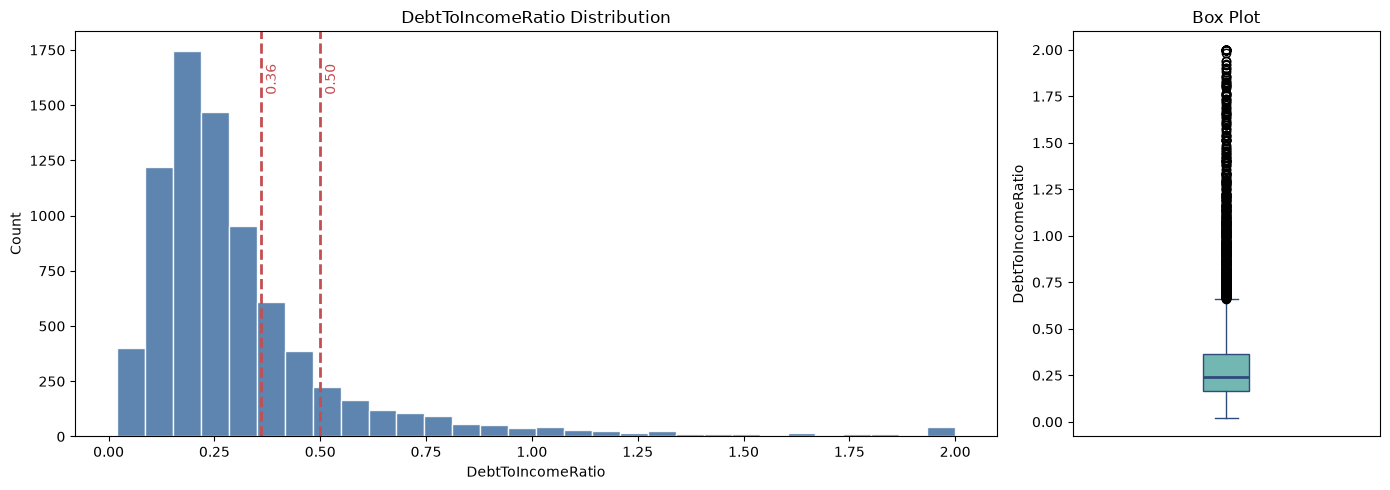

DebtToIncomeRatio percentiles (excluding missing values):
75th    0.3640
95th    0.8520
99th    1.6843


In [3]:
dti = df['DebtToIncomeRatio'].dropna()
dti_percentiles = dti.quantile([0.75, 0.95, 0.99]).rename({0.75: '75th', 0.95: '95th', 0.99: '99th'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

axes[0].hist(dti, bins=30, color='#4C78A8', edgecolor='white', alpha=0.9)
for ref in [0.36, 0.50]:
    axes[0].axvline(ref, color='#C44E52', linestyle='--', linewidth=2)
    axes[0].text(ref + 0.01, axes[0].get_ylim()[1] * 0.92, f'{ref:.2f}', color='#C44E52', rotation=90, va='top')
axes[0].set_title('DebtToIncomeRatio Distribution')
axes[0].set_xlabel('DebtToIncomeRatio')
axes[0].set_ylabel('Count')

axes[1].boxplot(dti, vert=True, patch_artist=True, boxprops={'facecolor': '#72B7B2', 'color': '#2F4B7C'}, medianprops={'color': '#2F4B7C', 'linewidth': 2}, whiskerprops={'color': '#2F4B7C'}, capprops={'color': '#2F4B7C'})
axes[1].set_title('Box Plot')
axes[1].set_ylabel('DebtToIncomeRatio')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print('DebtToIncomeRatio percentiles (excluding missing values):')
print(dti_percentiles.round(4).to_string())

## Approval Balance

This section records the counts and percentages for the target column.

In [4]:
approval_counts = df['Approval'].value_counts(dropna=False)
approval_percentages = (df['Approval'].value_counts(normalize=True, dropna=False) * 100).round(2)

approval_summary = pd.DataFrame({'count': approval_counts, 'percentage': approval_percentages})
print(approval_summary.to_string())

          count  percentage
Approval                   
Yes        4480        56.0
No         3520        44.0


## Approval Rate by FICO Band

CreditScore is binned into standard FICO bands and the approval rate is plotted for each band. Sample size is shown above each bar for context.

In [5]:
df['fico_band'] = pd.cut(df['CreditScore'], bins=fico_band_bins, labels=fico_band_labels, right=False)

fico_approval_summary = (
    df.groupby('fico_band', observed=False)
    .agg(
        count=('Approval', 'size'),
        approval_rate=('Approval', lambda s: (s.eq('Yes').mean() * 100)),
    )
    .reindex(fico_band_labels)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    fico_approval_summary.index.astype(str),
    fico_approval_summary['approval_rate'],
    color='#4C78A8',
    edgecolor='white',
)

for bar, count in zip(bars, fico_approval_summary['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'n={int(count)}',
        ha='center',
        va='bottom',
        fontsize=10,
    )

ax.set_title('Approval Rate by FICO Band')
ax.set_xlabel('FICO Band')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(fico_approval_summary.assign(approval_rate=fico_approval_summary['approval_rate'].round(2)).to_string())

           count  approval_rate
fico_band                      
<580        1774          11.22
580-619     1714          37.16
620-679     2746          72.40
680-739     1391          92.45
740+         375          98.67


## Correlation Matrix

This section computes correlations for all numerical columns except `ApplicationID`, shows the matrix as a heatmap, and lists pairs with absolute correlation above 0.30.

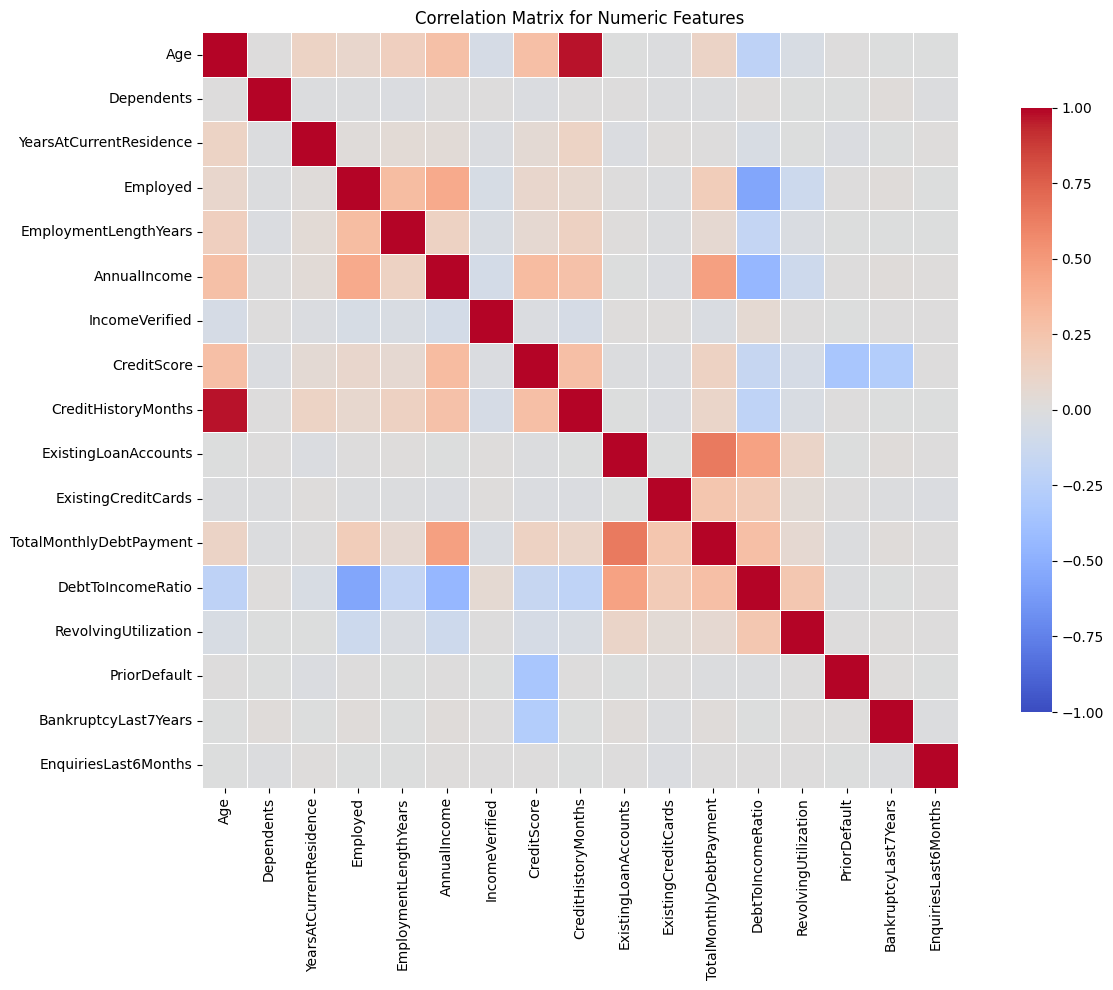

           feature_1               feature_2  correlation
                 Age     CreditHistoryMonths        0.974
ExistingLoanAccounts TotalMonthlyDebtPayment        0.642
            Employed       DebtToIncomeRatio       -0.556
        AnnualIncome TotalMonthlyDebtPayment        0.466
ExistingLoanAccounts       DebtToIncomeRatio        0.456
        AnnualIncome       DebtToIncomeRatio       -0.453
            Employed            AnnualIncome        0.408
         CreditScore            PriorDefault       -0.338
        AnnualIncome             CreditScore        0.311


In [7]:
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns.drop('ApplicationID', errors='ignore')
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Correlation Matrix for Numeric Features')
plt.tight_layout()
plt.show()

strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        value = corr_matrix.iat[i, j]
        if abs(value) > 0.30:
            strong_pairs.append({
                'feature_1': corr_matrix.index[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': round(value, 3),
            })

strong_corr_summary = pd.DataFrame(strong_pairs).sort_values('correlation', key=lambda s: s.abs(), ascending=False)
print(strong_corr_summary.to_string(index=False))
